In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/vehicle_registrations.csv", sep=";", encoding="utf-8", low_memory=False)

In [3]:
df = df.drop_duplicates()

Першим кроком у підготовці даних є видалення дублікатів за допомогою методу drop_duplicates(). Ця операція є критично важливою, оскільки під час попереднього аналізу якості даних (Data Quality Analysis) було виявлено 710 ідентичних записів. Такі повтори часто виникають внаслідок технічних особливостей вивантаження з реєстрів відкритих даних, і їхнє видалення дозволяє уникнути штучного завищення показників при статистичному аналізі.

In [4]:
for col in ['OWN_WEIGHT', 'TOTAL_WEIGHT', 'CAPACITY']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Дані завантажено. Поточний розмір датасету: {df.shape}")

Дані завантажено. Поточний розмір датасету: (314969, 20)


Наступним етапом є приведення типів даних до числових форматів для колонок, що містять інформацію про вагу (OWN_WEIGHT, TOTAL_WEIGHT) та об'єм двигуна (CAPACITY). Оскільки в сирому вигляді ці дані завантажуються як текст, використання функції pd.to_numeric із параметром errors='coerce' дозволяє коректно перетворити їх на числа для виконання математичних операцій. Це також автоматично замінює невалідні текстові символи на порожні значення (NaN), що запобігає збоям у роботі аналітичних інструментів. Виведення поточної кількості рядків і стовпців після очищення допомагає переконатися, що набір даних залишився цілісним і репрезентативним для подальшої перевірки гіпотез.

Топ-10 марок займають 54.36% ринку реєстрацій.
------------------------------
BRAND
VOLKSWAGEN       34227
RENAULT          18481
MERCEDES-BENZ    17250
BMW              16789
AUDI             16209
TOYOTA           15672
SKODA            14652
FORD             13652
NISSAN           12343
HYUNDAI          11927
Name: count, dtype: int64


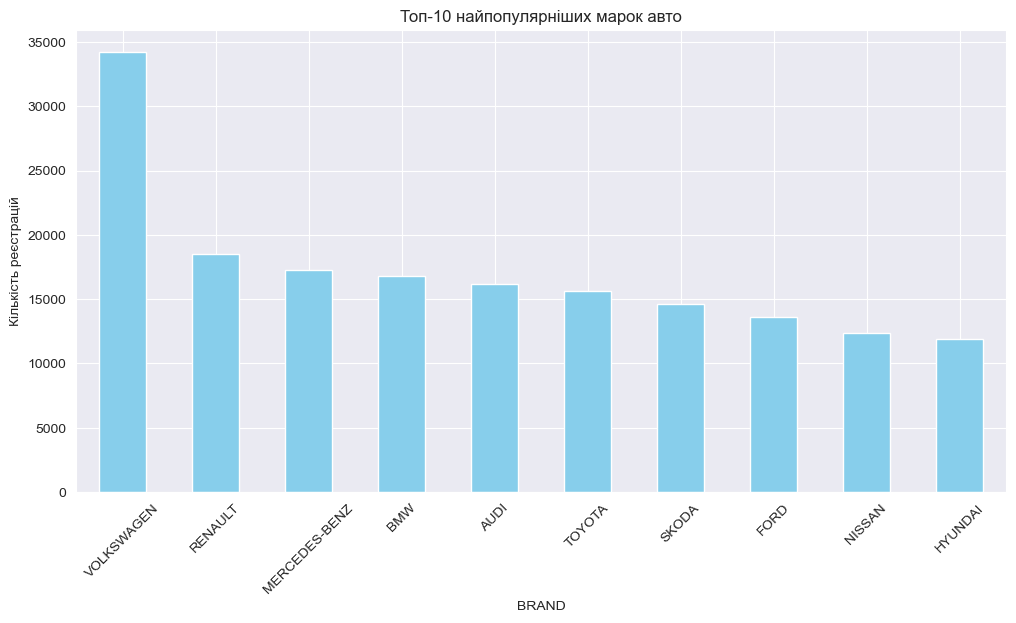

In [5]:
brand_counts = df['BRAND'].value_counts()
top_10_brands = brand_counts.head(10)

market_share_top_10 = (top_10_brands.sum() / len(df)) * 100

print(f"Топ-10 марок займають {market_share_top_10:.2f}% ринку реєстрацій.")
print("-" * 30)
print(top_10_brands)

plt.figure(figsize=(12, 6))
top_10_brands.plot(kind='bar', color='skyblue')
plt.title('Топ-10 найпопулярніших марок авто')
plt.ylabel('Кількість реєстрацій')
plt.xticks(rotation=45)
plt.show()

### **Гіпотеза 1:** Кілька великих виробників домінують у структурі зареєстрованих ТЗ, тоді як більшість брендів мають значно меншу частку.

Гіпотеза про домінування кількох ключових виробників повністю підтвердилася: лише 10 брендів контролюють понад половину ринку — 54.36% від усіх реєстрацій. Це свідчить про високу ринкову концентрацію, де більшість інших марок мають незначну частку.

Беззаперечним лідером є VOLKSWAGEN з показником 34 227 одиниць, що майже вдвічі перевищує результат найближчого переслідувача — RENAULT (18 481). До п'ятірки лідерів також увійшли німецькі бренди MERCEDES-BENZ, BMW та AUDI, що підкреслює стійку перевагу українських споживачів до європейського автопрому.

Решту першої десятки формують марки TOYOTA, SKODA, FORD, NISSAN та HYUNDAI. Хоча розрив між ними менший, вони все одно суттєво випереджають інші бренди. Така популярність лідерів зумовлена впізнаваністю брендів та доступністю сервісної інфраструктури.


In [6]:
valid_fuel = df[~df['FUEL'].isin(['.', 'ВІДСУТНЄ', 'НЕ ВИЗНАЧЕНО'])].copy()

fuel_counts = valid_fuel['FUEL'].value_counts()
fuel_pct = (fuel_counts / len(valid_fuel)) * 100

print("Частки типів пального:")
print(fuel_pct.round(2).astype(str) + '%')

ev_share = fuel_pct.get('ЕЛЕКТРО', 0)
print(f"\nВисновок: Частка електромобілів складає {ev_share:.2f}% від загальної кількості реєстрацій.")

Частки типів пального:
FUEL
БЕНЗИН                         39.96%
ДИЗЕЛЬНЕ ПАЛИВО                33.26%
БЕНЗИН АБО ГАЗ                 14.58%
ЕЛЕКТРО                         4.85%
ЕЛЕКТРО АБО БЕНЗИН              2.99%
ЕЛЕКТРО АБО ДИЗЕЛЬНЕ ПАЛИВО     0.52%
ГАЗ                             0.33%
БЕНЗИН, ГАЗ АБО ЕЛЕКТРО         0.11%
ДИЗЕЛЬНЕ ПАЛИВО АБО ГАЗ          0.0%
Name: count, dtype: object

Висновок: Частка електромобілів складає 4.85% від загальної кількості реєстрацій.


### **Гіпотеза 2:** Найбільшу частку складають автомобілі з бензиновими та дизельними двигунами, тоді як електричні та гібридні засоби мають значно меншу частку.

Аналіз розподілу типів пального повністю підтверджує гіпотезу про домінування традиційних двигунів внутрішнього згоряння. Сумарна частка автомобілів, що використовують виключно бензин (39.96%) та дизельне паливо (33.26%), становить понад 73% від усіх реєстрацій. Якщо врахувати категорію «Бензин або газ» (14.58%), то стає очевидним, що переважна більшість автопарку (майже 88%) критично залежить від викопного палива.

Частка екологічного транспорту залишається порівняно низькою, хоча й демонструє динаміку зростання. Чисті електромобілі займають 4.85% ринку, що є суттєвим показником для сучасного етапу розвитку інфраструктури, проте вони все ще поступаються традиційним видам палива у десятки разів. Гібридні рішення (електро у поєднанні з бензином або дизелем) сумарно охоплюють ще близько 3.5% реєстрацій.

Таким чином, результати підтверджують, що попри глобальні тренди на електрифікацію, український ринок залишається консервативним. Бензинові та дизельні авто становлять основу автопарку, тоді як електричні та гібридні моделі наразі займають лише вузьку нішу, загальна частка якої не перевищує 8.5% від загальної кількості реєстрацій.

Середній вік зареєстрованих авто: 14.3 років
Медіанний вік: 14 років


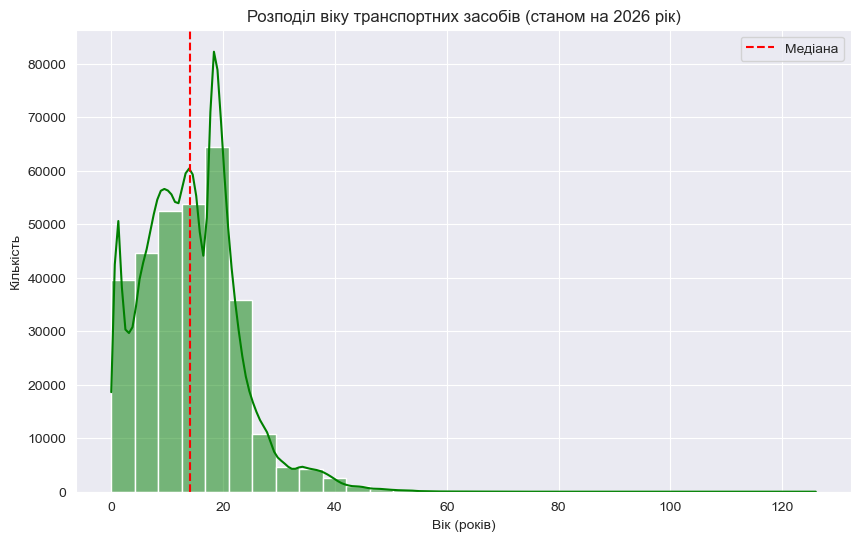

In [7]:
current_year = 2026
df['vehicle_age'] = current_year - df['MAKE_YEAR']

print(f"Середній вік зареєстрованих авто: {df['vehicle_age'].mean():.1f} років")
print(f"Медіанний вік: {df['vehicle_age'].median():.0f} років")

plt.figure(figsize=(10, 6))
sns.histplot(df['vehicle_age'], bins=30, kde=True, color='green')
plt.title('Розподіл віку транспортних засобів (станом на 2026 рік)')
plt.xlabel('Вік (років)')
plt.ylabel('Кількість')
plt.axvline(df['vehicle_age'].median(), color='red', linestyle='--', label='Медіана')
plt.legend()
plt.show()

### **Гіпотеза 3:** Більшість транспортних засобів у реєстрі має відносно великий вік, що може свідчити про значну частку ввезених вживаних автомобілів.

Результати розрахунків повністю підтверджують гіпотезу про значний вік транспортних засобів у реєстрі. Середній вік автомобілів становить 14.3 років, а медіанний показник зафіксовано на позначці 14 років. Це означає, що рівно половина всіх зареєстрованих засобів була випущена у 2012 році або раніше. Такий високий показник є типовим для ринків, де основу поповнення автопарку складає імпорт вживаних автомобілів, а не продаж нових транспортних засобів.

Графік розподілу наочно демонструє основний пік реєстрацій, який припадає на автомобілі віком від 15 до 20 років. Це свідчить про масове ввезення та перереєстрацію бюджетних моделей початку 2000-х років. Хоча на гістограмі помітні невеликі сплески у категорії відносно нових авто (0–5 років), вони значно поступаються за масовістю застарілим моделям, що підкреслює вторинність ринку.

Таким чином, вікова структура автопарку свідчить про його повільне оновлення. Переважання машин із 14-річним і більшим терміном експлуатації підтверджує, що вживані автомобілі є головним сегментом для українських власників. Це ставить перед дослідниками подальші питання щодо екологічності та технічного стану засобів, які становлять основу дорожнього руху.
